# Day 3: Advanced Models (The Power-Hitters)

### 1. 🚀 Setup and Imports

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report,accuracy_score

%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

### 2. 🧠 Core Concept: The Importance of Scaling (Again!)

**Recap:** KNN and SVM are "distance-based" models. A feature with a large scale (e.g., 'Salary' from 50k-200k) will completely dominate a feature with a small scale (e.g., 'Age' from 20-70).

**Action:** For this entire day (except Boosting), we *must* use `StandardScaler`.

**Task:** Load a classification dataset and perform the full workflow:
1. Load `X`, `y`
2. `train_test_split`
3. `scaler.fit(X_train)`
4. `X_train_scaled = scaler.transform(X_train)`
5. `X_test_scaled = scaler.transform(X_test)`

In [29]:
from sklearn.datasets import load_iris
iris = load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [30]:
X = iris.data 
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

---

### 3. 🤝 Model 1: K-Nearest Neighbors (KNN)

**Concept:** A "lazy learner." To classify a new point, it looks at the `k` (e.g., 5) training points closest to it and takes a majority vote.

**Task:** `KNeighborsClassifier`
1. Create an instance: `model_knn = KNeighborsClassifier(n_neighbors=5)`
2. Train on scaled data: `model_knn.fit(X_train_scaled, y_train)`
3. Make predictions: `y_pred_knn = model_knn.predict(X_test_scaled)`
4. Evaluate: Print the Classification Report.

In [34]:
model_knn = KNeighborsClassifier(n_neighbors = 4)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)

In [35]:
print(f"Classification Report :\n{classification_report(y_test,y_pred_knn)}")

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.88      1.00      0.94        15
           2       1.00      0.88      0.93        16

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50



**Task (Challenge):** How do you find the best `k`?
1. Create a loop for `k` from 1 to 20.
2. In the loop, train a new KNN model and record its test accuracy.
3. Use Matplotlib to plot the `k` value vs. Test Accuracy. (This is a manual way to find the "elbow").

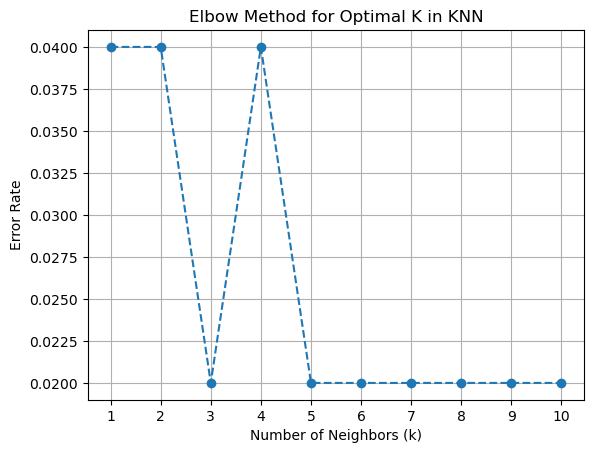

In [39]:
# Lets use Elbow Method!
k = range(1,11)
loss = []

for i in k:
    model_knn = KNeighborsClassifier(n_neighbors = i)
    model_knn.fit(X_train_scaled, y_train)
    y_pred = model_knn.predict(X_test_scaled)
    error_score = 1 - accuracy_score(y_test,y_pred)
    loss.append(error_score)

plt.plot(k, loss, marker = 'o', linestyle = '--')
plt.title('Elbow Method for Optimal K in KNN')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Error Rate')
plt.xticks(k)
plt.grid(True)
plt.show()

### Hence K = 3 is the best clusrter number, training again with K = 3

In [40]:
model_knn = KNeighborsClassifier(n_neighbors = 3)
model_knn.fit(X_train_scaled, y_train)
y_pred_knn = model_knn.predict(X_test_scaled)
print(f"Classification Report :\n{classification_report(y_test,y_pred_knn)}")

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.94      1.00      0.97        15
           2       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



---

### 4. 🛣️ Model 2: Support Vector Machines (SVM)

**Concept:** Tries to find the "widest possible street" (or hyperplane) that best separates the two classes.

**Task:** `SVC` (Support Vector Classifier) - Kernel 1: Linear
1. Create an instance: `model_svc_linear = SVC(kernel='linear')`
2. Train on scaled data: `model_svc_linear.fit(X_train_scaled, y_train)`
3. Predict and print the Classification Report.

In [47]:
model_svc_linear = SVC(kernel='linear')
model_svc_linear.fit(X_train_scaled, y_train)
y_pred_svc = model_svc_linear.predict(X_test_scaled)
print(f"Classification Report with Kernel : Linear:\n{classification_report(y_test,y_pred_svc)}")

Classification Report with Kernel : Linear:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.93      0.93      0.93        15
           2       0.94      0.94      0.94        16

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50



**Task:** `SVC` - Kernel 2: The "Kernel Trick" (RBF)
**Concept:** Projects the data into a higher dimension to *make* it separable.
1. Create an instance: `model_svc_rbf = SVC(kernel='rbf')`
2. Train on scaled data: `model_svc_rbf.fit(X_train_scaled, y_train)`
3. Predict and print the Classification Report. (This is usually more powerful).

In [48]:
model_svc_rbf = SVC(kernel='rbf')
model_svc_rbf.fit(X_train_scaled, y_train)
y_pred_svc = model_svc_rbf.predict(X_test_scaled)
print(f"Classification Report with Kernel : RBF:\n{classification_report(y_test,y_pred_svc)}")

Classification Report with Kernel : RBF:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.94      1.00      0.97        15
           2       1.00      0.94      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



### Comparison of Classification Reports for SVC with Different Kernels

#### Kernel: Linear
- **Precision**:
    - Class 0: 1.00
    - Class 1: 0.93
    - Class 2: 0.94
- **Recall**:
    - Class 0: 1.00
    - Class 1: 0.93
    - Class 2: 0.94
- **F1-Score**:
    - Class 0: 1.00
    - Class 1: 0.93
    - Class 2: 0.94
- **Accuracy**: 0.96
- **Macro Average**: 0.96
- **Weighted Average**: 0.96

#### Kernel: RBF
- **Precision**:
    - Class 0: 1.00
    - Class 1: 0.94
    - Class 2: 1.00
- **Recall**:
    - Class 0: 1.00
    - Class 1: 1.00
    - Class 2: 0.94
- **F1-Score**:
    - Class 0: 1.00
    - Class 1: 0.97
    - Class 2: 0.97
- **Accuracy**: 0.98
- **Macro Average**: 0.98
- **Weighted Average**: 0.98

#### Key Observations:
1. The **RBF kernel** achieves slightly better overall performance with an accuracy of 0.98 compared to 0.96 for the **Linear kernel**.
2. The **RBF kernel** has higher F1-scores for Class 1 and Class 2, indicating better balance between precision and recall for these classes.
3. Both kernels perform equally well for Class 0, achieving perfect precision, recall, and F1-scores.
4. The **RBF kernel** is generally more effective for this dataset, as it captures non-linear relationships better than the Linear kernel.

---

### 5. 🚀 Model 3: Gradient Boosting

**Concept:** The "boss level" ensemble. Builds trees *sequentially*. Each new tree's job is to fix the errors made by all the previous trees.

**Task:** `HistGradientBoostingClassifier`
**Note:** This is Scikit-learn's modern, fast version. It handles unscaled data and missing values automatically. **No scaling needed!**
1. Create an instance: `model_hgb = HistGradientBoostingClassifier(random_state=42)`
2. Train on the *unscaled* data: `model_hgb.fit(X_train, y_train)`
3. Make predictions: `y_pred_hgb = model_hgb.predict(X_test)`
4. Evaluate: Print the Classification Report.

In [49]:
model_hgb = HistGradientBoostingClassifier(random_state=42)
model_hgb.fit(X_train, y_train)
y_pred_hgb = model_hgb.predict(X_test)
print(f"Classification Report with Kernel : RBF:\n{classification_report(y_test,y_pred_hgb)}")

Classification Report with Kernel : RBF:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.83      1.00      0.91        15
           2       1.00      0.81      0.90        16

    accuracy                           0.94        50
   macro avg       0.94      0.94      0.94        50
weighted avg       0.95      0.94      0.94        50



**Task (Self-Study Note):**
Note the names of the industry-standard libraries: `XGBoost` (`xgboost.XGBClassifier`) and `LightGBM` (`lightgbm.LGBMClassifier`). They are built on the same "boosting" principle.